In [1]:
# 1
import pandas as pd
import numpy as np
Dataset = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}
data = pd.DataFrame(Dataset)
total_number_purchase = data.groupby("Customer_ID")["Purchase_Amount"].sum().reset_index()
top_3 = total_number_purchase.sort_values(by="Purchase_Amount", ascending = False).head(3)

In [2]:
total_number_purchase

,Customer_ID,Purchase_Amount
0,101,520
1,102,600
2,103,480
3,104,300
4,105,400


In [3]:
top_3

,Customer_ID,Purchase_Amount
1,102,600
0,101,520
2,103,480


In [4]:
# 2
import pandas as pd
import numpy as np
data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}

data = pd.DataFrame(data)

# Calculate Q1 and Q3
Q1, Q3 = np.percentile(data["Sales"], [25, 75])
print('Q1:', Q1, 'Q3:', Q3)

# Calculate IQR
IQR = Q3 - Q1
print('IQR', IQR)

# Find Lower Bound and Upper Bound
Lower_bound = Q1 - 1.5 * IQR 
Upper_bound = Q3 + 1.5 * IQR
print('Lower_bound =', Lower_bound , 'Upper_bound =', Upper_bound)

# Detect and display outliers
Outliers = data[(data["Sales"] < Lower_bound) | (data["Sales"] > Upper_bound)]
print("Outliers Detected:", Outliers)

# Replace outliers with median value
Med_value = data["Sales"].median()

data['Sales'] = data['Sales'].apply(
    lambda x: Med_value if x < Lower_bound or x > Upper_bound else x)

print("Data After Replacing Outliers with Median:" , data)

Q1: 31.5 Q3: 83.75
IQR 52.25
Lower_bound = -46.875 Upper_bound = 162.125
Outliers Detected:     Day  Sales
29   30    200
Data After Replacing Outliers with Median:     Day  Sales
0     1   25.0
1     2   30.0
2     3   28.0
3     4   45.0
4     5   55.0
5     6   60.0
6     7   22.0
7     8   80.0
8     9   95.0
9    10  120.0
10   11   33.0
11   12   29.0
12   13   27.0
13   14   35.0
14   15   40.0
15   16   50.0
16   17   85.0
17   18  110.0
18   19  105.0
19   20   92.0
20   21   30.0
21   22   34.0
22   23   31.0
23   24   33.0
24   25   36.0
25   26   42.0
26   27   44.0
27   28   48.0
28   29   90.0
29   30   43.0


In [5]:
# 3
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}

Data = pd.DataFrame(data)

treatment = Data[Data['Group'] == 'Treatment']['Blood_Pressure']
control = Data[Data['Group'] == 'Control']['Blood_Pressure']

t_stat, p_value = ttest_ind(treatment, control)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value<0.05:
    print("Reject null Hypothesis")
    print("The drug has a significant effect")
else:
    print("Reject null hypothesis accept alternate hypothesis")
    print("The drug has no significant effect")

T-Statistic: -11.870553692962726
P-Value: 6.008066605173374e-10
Reject null Hypothesis
The drug has a significant effect


In [7]:
# 4
import pandas as pd
import numpy as np

data = {
    'Region': ['North', 'South', 'East', 'West', 'Central'],
    'TV_Ad_Budget': [200, 300, 400, 500, 600],
    'Social_Media_Budget': [150, 250, 300, 450, 500],
    'Sales': [20, 35, 50, 60, 80]
}

Data = pd.DataFrame(data)

COV = Data[['TV_Ad_Budget', 'Social_Media_Budget', 'Sales']].cov()
Cov_TV_sales = COV.loc['TV_Ad_Budget', 'Sales']
Cov_Social_sales = COV.loc['Social_Media_Budget', 'Sales']

print(f"Covariance (TV vs Sales): {Cov_TV_sales}")
print(f"Covariance (Social Media vs Sales): {Cov_Social_sales}")


CORR = Data[['TV_Ad_Budget', 'Social_Media_Budget', 'Sales']].corr()
Corr_TV_sales = CORR.loc['TV_Ad_Budget', 'Sales']
Corr_Social_sales = CORR.loc['Social_Media_Budget', 'Sales']

print(f"Correlation (TV vs Sales): {Corr_TV_sales}")
print(f"Correlation (Social Media vs Sales): {Corr_Social_sales}")

#We use correlation instead of covariance because correlation is scale-independent and better for comparing strength of relationships.
if Corr_TV_sales > Corr_Social_sales:
    print("TV Ads have a stronger impact on Sales.")
elif Corr_Social_sales > Corr_TV_sales:
    print("Social Media Ads have a stronger impact on Sales.")
else:
    print("Both ad types are equally effective.")

Covariance (TV vs Sales): 3625.0
Covariance (Social Media vs Sales): 3225.0
Correlation (TV vs Sales): 0.9958640886279954
Correlation (Social Media vs Sales): 0.9724846021568382
TV Ads have a stronger impact on Sales.


Mean Delivery Time: 65.0625
Standard Deviation of Delivery Time: 41.718504212759115


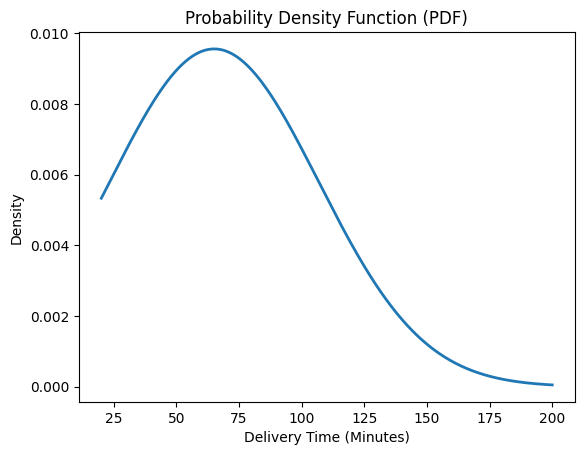

In [6]:
# 5
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

dataset = [25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 
          20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]

mean_time = np.mean(dataset)
std_time = np.std(dataset)
print("Mean Delivery Time:", mean_time)
print("Standard Deviation of Delivery Time:", std_time)

x = np.linspace(min(dataset),max(dataset),500)

pdf = norm.pdf(x, mean_time, std_time)

plt.plot(x, pdf, linewidth=2)

plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Density")
plt.title("Probability Density Function (PDF)")

plt.show()

In [12]:
import numpy as np
data = [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
Q1, Q3 = np.percentile(data , [25, 75])
IQR = Q3 - Q1
Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR
Outlier = [x for x in data if x < Lower_bound or x > Upper_bound]
print ("Outlier:", Outlier)

Outlier: []


77.5